In [1]:
import h5py
import numpy as np
import napari
import matplotlib.pyplot as plt

## Load Fusion Image

In [2]:
path = r"C:\Users\delgr\Desktop\01_OPI-2601_250226_FUS_152842.h5"


In [3]:
f = h5py.File(path)
fusi = f['image'][:]
print('Image Loaded.  Size:', fusi.shape)

Image Loaded.  Size: (50, 64, 54, 1000)


### Preview a Slice

C:\Users\delgr\AppData\Local\Temp\ipykernel_28252\872755863.py:3: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(fusi[:, :, idx, time]), cmap='gray');


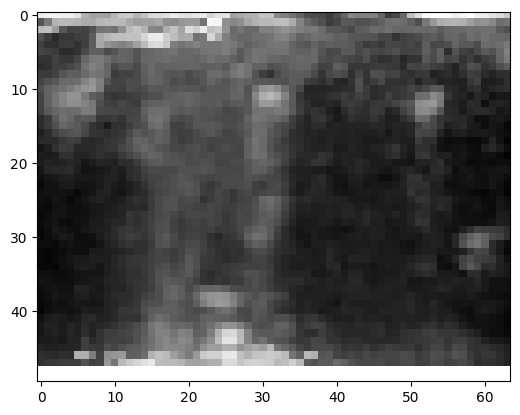

In [4]:
time = 0
idx = 26
plt.imshow(np.log(fusi[:, :, idx, time]), cmap='gray');

## Select Rows for Cortex Slice and Max Projection

In [5]:

top_idx = 5
bottom_idx = 12
cortex = fusi[top_idx:bottom_idx, :, :, :]


### Preview Cortex Slice

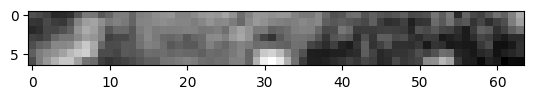

In [6]:
time = 0
idx = 26
plt.imshow(np.log(cortex[:, :, idx, time]), cmap='gray');

## Calculate Max Projection

In [7]:

cortex_max_proj = np.max(cortex, axis=0)
cortex_max_proj.shape


(64, 54, 1000)

### Preview Max Projection

C:\Users\delgr\AppData\Local\Temp\ipykernel_28252\93654040.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(cortex_max_proj[:, :, time]), cmap='gray');


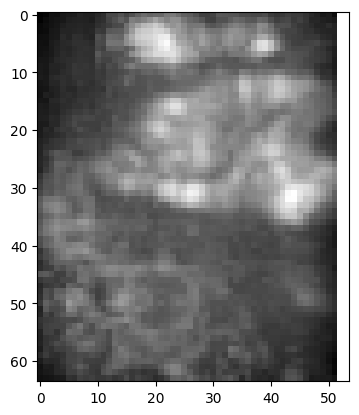

In [8]:
time = 10
plt.imshow(np.log(cortex_max_proj[:, :, time]), cmap='gray');


## Visualize Cortex Max Projection over Time in Napari


In [9]:
viewer = napari.Viewer()

In [10]:
image = np.log(cortex_max_proj)
viewer.add_image(image)


C:\Users\delgr\AppData\Local\Temp\ipykernel_28252\858911378.py:1: RuntimeWarning: divide by zero encountered in log
  image = np.log(cortex_max_proj)


<Image layer 'image' at 0x16a8a66aa50>

### Extract Rect ROIS

(Make a Shapes Layer in Napari, and put one rectangle)

In [36]:
rois = {}

for layer in viewer.layers:
    if isinstance(layer, napari.layers.shapes.shapes.Shapes) :
        print(layer.name)
        rect = layer.data[0]
        rect_rows = slice(int(rect[:, 0].min()), int(rect[:, 0].max()))
        rect_cols = slice(int(rect[:, 1].min()), int(rect[:, 1].max()))
        rois[layer.name] = image[rect_rows, rect_cols, :]
        

ROI1
Hippo
Dark


### Make Plot over Time

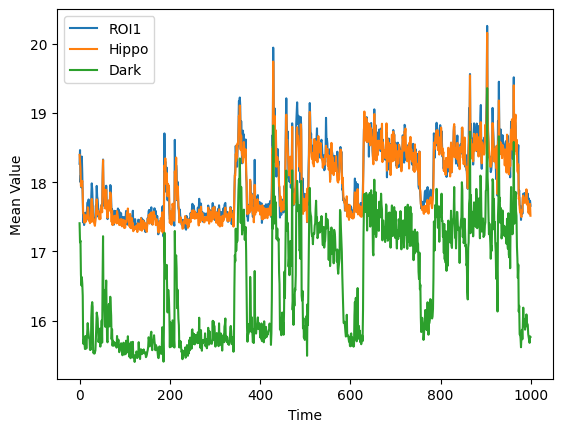

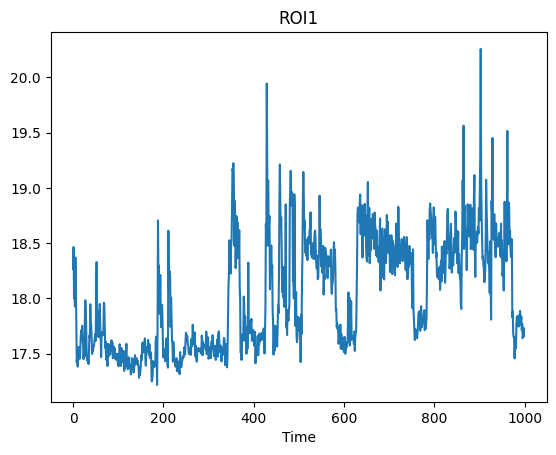

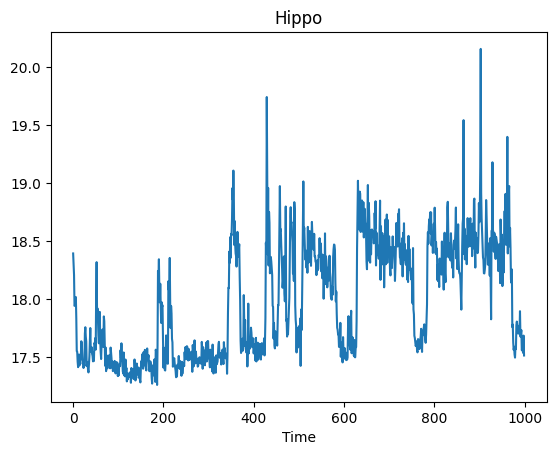

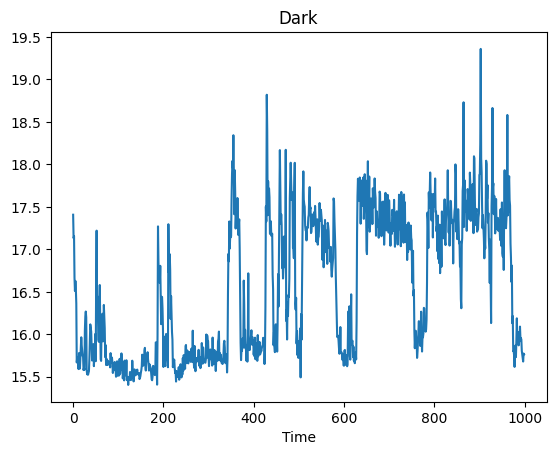

In [37]:
plt.figure()
for name, roi in rois.items():
    roi_mean = np.mean(roi, axis=(0, 1))
    plt.plot(roi_mean, label=name);
    plt.xlabel('Time')
    plt.ylabel('Mean Value')
plt.legend()

for name, roi in rois.items():
    plt.figure()
    roi_mean = np.mean(roi, axis=(0, 1))
    plt.plot(roi_mean);
    plt.title(name)
    plt.xlabel('Time')



        